# Project A3 “Motor imagery classification from EEG for brain computer interface”

## Introduction

Motor Imagery (MI) refers to the mental simulation of movement without any actual physical execution. EEG-based MI classification is a core component of Brain–Computer Interface (BCI) systems, enabling direct communication between the brain and external devices by decoding neural activity patterns associated with imagined movements.

In this notebook, we explore different end-to-end pipelines for **EEG Motor Imagery classification using Python**. The workflow includes EEG data loading, preprocessing, feature extraction, and supervised machine learning–based classification. 

In [1]:
import importlib
import scipy.io
import utils.utils as u 
import utils.preprocessing as p 
import utils.models as m 
import numpy as np
import mne
import polars as pl
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
import random
import matplotlib.pyplot as plt
from mne.decoding import CSP

# Reload modules to reflect recent changes:
importlib.reload(u)
importlib.reload(p)
importlib.reload(m)

SEED=42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

## Data loading
We will start by loading the dataset. This dataset is divided in 3 different experiments:

- CLA -  Left and Right hand movement, or passive (3 classes)
- HaLT - Left and Right hand/leg, tongue and passive (6 classes)
- 5F -  Five fingers movement (more challenging) (5 classes)

The files are coming from MatLab, which makes them have some additional metadata that we will have to get rid of. Additionally, the file names give us some information about the patients. Since we are experimenting on the eeg signals alone, we will not use this information, even if it could potentially boost our results.

The dataset contains EEG recordings stored as a two-dimensional MATLAB array of size nS × 22, where each column represents a time series of voltage measurements from a single EEG channel. The recording includes 19 EEG leads arranged according to the international 10–20 system, two reference (ground) electrodes (A1 and A2), and one synchronization channel (X3 or X5). The synchronization channel does not contain physiological data and should be used solely to verify temporal alignment between the EEG data and the corresponding marker information.

Reference paper of the dataset: [Kaya18] Kaya, M., et al. A large electroencephalographic motor imagery
dataset for electroencephalographic brain computer interfaces, in Scientific
data, vol. 5, no. 1, pp. 1–16, 2018. 

https://www.researchgate.net/publication/328328921_A_large_electroencephalographic_motor_imagery_dataset_for_electroencephalographic_brain_computer_interfaces

All decisions taken in this notebook are based on different papers. The main paper that we follow as a general guideline is the following one:

[Altaheri23] H. Altaheri et al., Deep learning techniques for classification of
electroencephalogram (EEG) motor imagery (MI) signals: A review, Neural
Computing and Applications, vol. 35, no. 20, pp. 14681–14722, 2023

https://www.researchgate.net/publication/353327259_Deep_Learning_Techniques_for_Classification_of_Electroencephalogram_EEG_Motor_Imagery_MI_Signals_A_Review

This paper will be the backbone of our decisions regarding preprocessing, feature extraction and model selection. During the process we will refer to this paper often as [Altaheri23] and also refer to other papers that tackle specific problems.

 _NOTE: In the notebook some of the functions, that we though to be redundant are coming from additional python files, intending to make the code clearer and easier to follow. You can check this functions in the complementary python files if needed_

In [ ]:
# Get the file names from directory of the files of the experiment
files=u.get_file_names("../data", experiment="CLA")
print(files)

['../data/CLA-SubjectA-160108-3St-LRHand.mat', '../data/CLA-SubjectB-151019-3St-LRHand.mat', '../data/CLA-SubjectB-151020-3St-LRHand.mat', '../data/CLA-SubjectB-151215-3St-LRHand.mat', '../data/CLA-SubjectC-151126-3St-LRHand.mat', '../data/CLA-SubjectC-151216-3St-LRHand.mat', '../data/CLA-SubjectC-151223-3St-LRHand.mat', '../data/CLA-SubjectD-151125-3St-LRHand.mat', '../data/CLA-SubjectE-151225-3St-LRHand.mat', '../data/CLA-SubjectE-160119-3St-LRHand.mat', '../data/CLA-SubjectE-160122-3St-LRHand.mat', '../data/CLA-SubjectF-150916-3St-LRHand.mat', '../data/CLA-SubjectF-150917-3St-LRHand.mat', '../data/CLA-SubjectF-150928-3St-LRHand.mat', '../data/CLA-SubjectJ-170504-3St-LRHand-Inter.mat', '../data/CLA-SubjectJ-170508-3St-LRHand-Inter.mat', '../data/CLA-SubjectJ-170510-3St-LRHand-Inter.mat']


In [42]:
FILE=files[0] #TO DO: Choose one file for now, later we will loop over all files
mat_data = scipy.io.loadmat(FILE)

# The file includes metadata coming from python that we don't need.
# We will focus on the 'o' key which contains the EEG data and information about the experiment.

data = mat_data['o'][0, 0]       
print(f"Data keys include:{data.dtype.names}.\n") 
sfreq = int(data['sampFreq'][0, 0]) if data['sampFreq'].size > 0 else 200
eeg_data = data['data'].T  # Shape: (n_channels, n_samples)
channel_names = [
    str(ch[0]).strip("[]' ")
    for ch in data["chnames"]
]
info = mne.create_info(
            ch_names=channel_names,
            sfreq=sfreq,
            ch_types='eeg'
        )
        
info.set_channel_types({"X5": "misc"}) # Set 'X5' as misc type to avoid errors
montage = mne.channels.make_standard_montage('standard_1020') # Set standard 10-20 montage
info.set_montage(montage)
raw = mne.io.RawArray(eeg_data, info)
print(raw.info)

Data keys include:('id', 'tag', 'sampFreq', 'nS', 'marker', 'data', 'chnames', 'binsuV').

Creating RawArray with float64 data, n_channels=22, n_times=671600
    Range : 0 ... 671599 =      0.000 ...  3357.995 secs
Ready.
<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, A1, A2, F7, F8, T3, ...
 chs: 21 EEG, 1 misc
 custom_ref_applied: False
 dig: 24 items (3 Cardinal, 21 EEG)
 highpass: 0.0 Hz
 lowpass: 100.0 Hz
 meas_date: unspecified
 nchan: 22
 projs: []
 sfreq: 200.0 Hz
>


C:\Users\josub\AppData\Local\Temp\ipykernel_24244\2525920758.py:21: RuntimeWarning: The unit for channel(s) X5 has changed from V to NA.
  info.set_channel_types({"X5": "misc"}) # Set 'X5' as misc type to avoid errors


# PREPROCESSING

First of all, as the dataset paper suggests, let's check if the syncronization is correct. First let's check if all the marker arrays are of the same length. As we will see, they are close but not perfect.

In [45]:
labels = np.array(data['marker'])
import numpy as np
from itertools import groupby
grouped_data = []
for k, g in groupby(labels):
    series_length = len(list(g))
    grouped_data.append((k, series_length))
for marker, length in grouped_data[:10]:
    if marker != 0:  # Only print non-zero markers
        print(f"Marker {marker}: Length {length}")
non_zero_lengths = [length for k, length in grouped_data if k != 0]
if non_zero_lengths:
    print(f"\nMinimum length of a non-zero marker series: {min(non_zero_lengths)}")
    


Marker [3]: Length 203
Marker [3]: Length 203
Marker [1]: Length 203
Marker [1]: Length 204
Marker [2]: Length 203

Minimum length of a non-zero marker series: 202


As seen the markers are not of the same length, which is suspicious. Let's check if the syncronization is correct.

Sync channel data (first 10 samples): [-0. -0. -0. -0. -0. -0. -0. -0. -0. -0.]
Spike indixes:[1855 1856 1857 1858 1859 1860 1861 1862 3060 3061]
Compute gaps:[   1    1    1    1    1    1    1 1198    1    1]
Indices in gaps:[ 7 18 42 72 73 74 76 78 81 84]
Spike onsets in the plotted window: [100399 101084 101634]


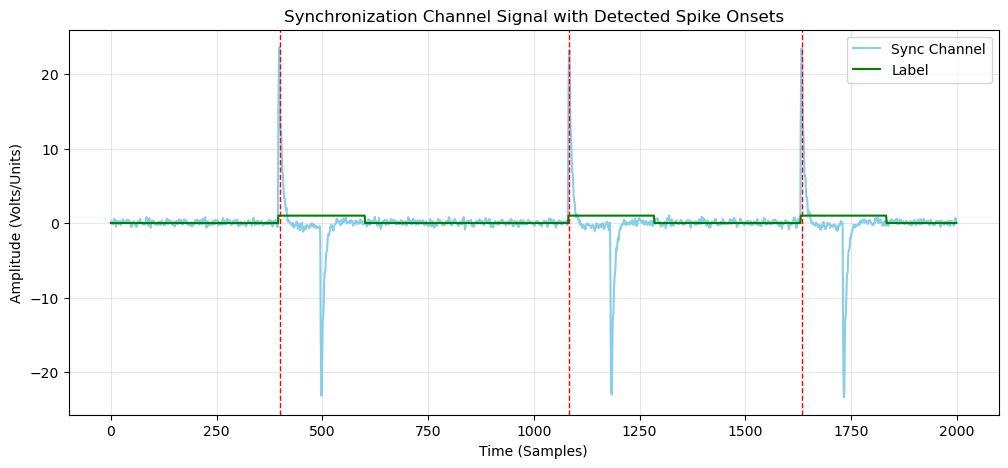

In [46]:
COLOR_MAP = {
    0: 'gray',    # Baseline/Rest
    1: 'blue',    # Mental Imagery 1
    2: 'red',     # Mental Imagery 2
    3: 'green',   # Mental Imagery 3 
}
THRESHOLD=20
sync_data = raw.get_data(picks='X5').flatten()
print(f"Sync channel data (first 10 samples): {sync_data[:10]}")
spikes=np.where(sync_data> 20)[0]
print(f"Spike indixes:{spikes[:10]}")
gaps = np.diff(spikes)
print(f"Compute gaps:{gaps[:10]}")

indices_in_gaps = np.where(gaps > 2)[0]
print(f"Indices in gaps:{indices_in_gaps[:10]}")
first_spike= spikes[0]
subsequent_spikes = spikes[indices_in_gaps]
final_spike_onsets = np.concatenate([[first_spike], subsequent_spikes])


START_OFFSET = 100000
WINDOW= 2000
plt.figure(figsize=(12, 5))
plt.plot(range(WINDOW), sync_data[START_OFFSET: START_OFFSET+WINDOW], label='Sync Channel', color='skyblue')
plt.plot(range(WINDOW), data["marker"][START_OFFSET: START_OFFSET+WINDOW], label='Label', color='green')

spikes_plot = final_spike_onsets[(final_spike_onsets >= START_OFFSET) & (final_spike_onsets < START_OFFSET + WINDOW)]
print(f"Spike onsets in the plotted window: {spikes_plot}")
for onset in spikes_plot:
    # Only label the first vertical line for a clean legend
    plt.axvline(x=onset-START_OFFSET, color='red', linestyle='--', linewidth=1)


plt.title('Synchronization Channel Signal with Detected Spike Onsets')
plt.xlabel('Time (Samples)')
plt.ylabel('Amplitude (Volts/Units)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



The syncronization seems to be right we just need to change the length of the windows to be consistent. We will do this later, since we will use a mne object called Epochs which will help us to cut our eeg data in even slices to classify. For this we will need to create an events object with the labels and the first marker index of each event. We will filter out the 0 label parts in this step too.

In [48]:
markers_diff = np.diff(data["marker"].squeeze())
all_transition_indices = np.where(markers_diff != 0)[0] + 1
all_values = data["marker"].squeeze()[all_transition_indices]
valid_mask = all_values != 0 #WE ARE TAKING ONLY NON-ZERO EVENTS
event_samples_filtered = all_transition_indices[valid_mask]
event_values_filtered = all_values[valid_mask]

# 4. Reconstruct the events array
event_count = len(event_samples_filtered)
events = np.column_stack([
    event_samples_filtered, 
    np.zeros(event_count, dtype=int), 
    event_values_filtered
]).astype(int)

print(f"Total Meaningful Events Found: {event_count}")
print(f"Unique Labels Found: {np.unique(event_values_filtered)}")
print(f"Events (first 10):\n{events[:10]}")


Total Meaningful Events Found: 960
Unique Labels Found: [1 2 3]
Events (first 10):
[[37272     0     3]
 [37783     0     3]
 [38370     0     1]
 [39022     0     1]
 [39555     0     2]
 [40111     0     1]
 [40695     0     2]
 [41278     0     2]
 [41815     0     1]
 [42342     0     1]]


Quoting [Altaheri23]: "Pre-processing is generally performed in three main 
steps: channel selection, signal frequency filtering, and 
artifact removal."

One big candidate here is using the PREP pipeline, which was created as standarized preprocessing for EEG:

[ N. Bigdely-Shamlo, T. Mullen, C. Kothe, K. M. Su, and K. A. Robbins, \The prep pipeline: Standardized preprocessing for large-scale eeg analysis," Frontiers in Neuroinformatics, vol. 9, no. 16, 2015.]

https://www.frontiersin.org/journals/neuroinformatics/articles/10.3389/fninf.2015.00016/full

However our dataset does not seem a good candidate. Let's see why, going through the steps of the PREP pipeline
1. Line Noise Removal (Unwanted electrical interference from the power supply in the environment) 
 However or data has been already notched at 50Hz, so we can skip this step.  (From the paper: "These are the hardware filters and therefore part of all the published records. Additionally, a 50 Hz notch filter is present in the EEG-1200 hardware to reduce electrical grid interference.")
 #A high-pass cutoff has not been passed.  THIS CAN BE DONE
2. Robust Referencing 
 Robust referencing is essentialy a normalization, between the channels considered not bad. However, we will not do robust refencing. In the dataset paper technical validation section, which we closelly look since it is a similar experiment in the same data as ours, they followed the following pipeline and methodology:

[Mishchenko] Mishchenko, Y., Kaya, M., Ozbay, E. & Yanar, H. Developing a 3- to 6-state EEG-based brain-computer interface for a virtual
robotic manipulator control. IEEE Trans Biomed Eng. Epub ahead of print, https://doi.org/10.1109/TBME.2018.2865941
(2018).

https://www.researchgate.net/publication/319878377_Developing_a_3-_to_6-state_EEG-based_brain-computer_interface_for_a_robotic_manipulator_control

In this paper, after experimenting with several referencing systems, Laplace refencing is suggested as having the overall best performance. 

#3. Bad Channel Interpolation
THIS CAN BE DONE

(#4. Rereferencing or undo interpolation)



In [ ]:
eeg_channels = [ch for ch in channel_names if ch not in ['X5','X3']]
# --- Laplace Reference (Surface Laplacian) ---
# In MNE, this is often done by calculating the Surface Laplacian.
raw_laplace = mne.preprocessing.compute_current_source_density(raw.copy().pick("eeg"))

EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Fitted sphere radius:         95.6 mm
Origin head coordinates:      -0.9 15.8 45.4 mm
Origin device coordinates:    -0.9 15.8 45.4 mm


Here we create the Epochs object (splitting the data in equivalent length slices), the tmin and tmax have been chosen as [Mishchenko] and the technical validation suggest it as the best windowing: "As described in Results, the
decoding data frame choice of t1= 0sec and t2= 0.85sec
was found to offer the best overall performance for all subjects
and all mental imageries."

In [ ]:
epochs_laplace = mne.Epochs(
    raw=raw_laplace,
    events=events,
    tmin=0,
    tmax=0.85,
    baseline=None,
    preload=True
)

Not setting metadata
1920 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 1920 events and 171 original time points ...
0 bad epochs dropped
Not setting metadata
1920 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 1920 events and 171 original time points ...
0 bad epochs dropped
Not setting metadata
1920 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 1920 events and 171 original time points ...
0 bad epochs dropped


In [ ]:
#Transform the epochs to numpy arrays
X = epochs_laplace.get_data()  # (n_epochs, n_channels, n_times)
y= epochs_laplace.events[:, 2]

Now let's do data augmentation. Data augmentation helps address overfitting by artificially increasing the diversity of the training data while preserving the underlying physiological characteristics of the signals. By introducing controlled variations models become more robust to inter-trial and inter-subject variability, ultimately improving classification performance and stability in EEG motor imagery tasks.

For data augmentation we will refer to one of the papers suggested by the teachers in the project presentation:

[Zhang21] C. Zhang, Y.-K. Kim, and A. Eskandarian, EEG-inception: an accurate and robust end-to-end 
neural network for EEG-based motor imagery classification, Journal of Neural Engineering, vol. 18, no. 
4, p. 046014, 2021.

https://www.researchgate.net/publication/348802845_EEG-Inception_An_Accurate_and_Robust_End-to-End_Neural_Network_for_EEG-based_Motor_Imagery_Classification

They used an 8th-order Butterworth high-pass filter with a cut-off frequency of 100 Hz (in our case 90Hz due to our low frequency rate) to first extract noise candidates. The extracted noise components are then subtracted from the original EEG signals and another random noise candidate is  added to the signal. This way by substracting and adding different noise, we can generate up to n-1 times more data. In our case we will just increasy times 3.

In [ ]:
import numpy as np
from scipy.signal import butter, filtfilt

def augment_eeg_data(X, y, multiplier=3):
    n_trials, n_chans, n_samples = X.shape
    
    # 1. Extract Noise (>90Hz) from all trials (We can't do 100Hz because original data is sampled at 200Hz)
    b, a = butter(8, 90, btype='high', fs=sfreq)
    noise_candidates = filtfilt(b, a, X, axis=-1)
    
    # 2. Extract Clean Signals (<90Hz)
    clean_signals = X - noise_candidates
    
    X_aug_list = [X] # Start with original data
    y_aug_list = [y]
    
    for _ in range(multiplier - 1):
        # Create a randomized version of the dataset
        X_new = np.zeros_like(X)
        for i in range(n_trials):
            # Pick a random trial k to get noise from
            k = np.random.randint(0, n_trials)
            # S_aug = Clean_i + Noise_k
            X_new[i] = clean_signals[i] + noise_candidates[k]
        
        X_aug_list.append(X_new)
        y_aug_list.append(y)
        
    return np.concatenate(X_aug_list, axis=0), np.concatenate(y_aug_list, axis=0)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

unique_labels = np.unique(y)
N = len(unique_labels)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp)
X_train, y_train = augment_eeg_data(X_train, y_train, multiplier=3) #WE AUGMENT ONLY THE TRAINING SET

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y),
    y=y
)

# Convert to dict {class_index: weight}
class_weights = dict(enumerate(class_weights_array))
print(class_weights)

print(X_train.shape, X_val.shape, X_test.shape)


{0: 0.5, 1: 1.5894039735099337, 2: 1.411764705882353, 3: 1.509433962264151}
(4032, 21, 171) (288, 21, 171) (288, 21, 171)


EXTRACTED FEATURES

In [15]:
from joblib import Parallel, delayed
freq_bands = [[4, 8], [8, 12], [12, 16], [16, 20], [20, 24], [24, 28], [28, 32], [32,36], [36,40]]
all_sequences = []

# 1. Initialize storage
trained_csp_bank = []
train_seq, val_seq, test_seq = [], [], []

def extract_windows(data, n_steps=10):
    n_samples = data.shape[-1]
    win_len = int(n_samples * 0.5) 
    start_indices = np.linspace(0, n_samples - win_len, n_steps).astype(int)
    
    sections = []
    for start in start_indices:
        sections.append(data[..., start:start+win_len])
    return sections

def process_band_to_matrix(low, high, X_train, y_train, X_val, X_test, sfreq):
    # Filter
    xt_b = mne.filter.filter_data(X_train, sfreq, low, high, method='iir', verbose=False)
    xv_b = mne.filter.filter_data(X_val, sfreq, low, high, method='iir', verbose=False)
    xte_b = mne.filter.filter_data(X_test, sfreq, low, high, method='iir', verbose=False)

    csp = CSP(n_components=4, reg='ledoit_wolf', log=True)
    csp.fit(xt_b, y_train)
    W = csp.filters_ 

    def get_matrices(dataset):
        cnn_mats = []
        rnn_mats = []
        
        for trial in dataset:
            # Generate CNN windows (T=3)
            sec_cnn = extract_windows(trial, n_steps=3)
            # Generate RNN windows (T=10) - SWC Strategy
            sec_rnn = extract_windows(trial, n_steps=15)
            
            # Helper to calculate log-var for a list of sections
            def calc_logvar(sections):
                cols = []
                for sec in sections:
                    proj = np.dot(W, sec)
                    cols.append(np.log(np.var(proj, axis=1)))
                return np.stack(cols, axis=1) # Shape: (Components, T)

            cnn_mats.append(calc_logvar(sec_cnn))
            rnn_mats.append(calc_logvar(sec_rnn))
            
        return np.array(cnn_mats), np.array(rnn_mats)

    train_cnn, train_rnn = get_matrices(xt_b)
    val_cnn, val_rnn     = get_matrices(xv_b)
    test_cnn, test_rnn   = get_matrices(xte_b)

    return (train_cnn, val_cnn, test_cnn), (train_rnn, val_rnn, test_rnn)

# --- Parallel Execution ---
results = Parallel(n_jobs=-1)(delayed(process_band_to_matrix)(l, h, X_train, y_train, X_val, X_test, sfreq) 
                              for l, h in freq_bands)
# Extract CNN data: index r[0] contains (train, val, test)
X_train_cnn = np.concatenate([r[0][0] for r in results], axis=1) # (Trials, 36, 3)
X_val_cnn   = np.concatenate([r[0][1] for r in results], axis=1)
X_test_cnn  = np.concatenate([r[0][2] for r in results], axis=1)

# Extract RNN data: index r[1] contains (train, val, test)
X_train_rnn = np.concatenate([r[1][0] for r in results], axis=1) # (Trials, 36, 15)
X_val_rnn   = np.concatenate([r[1][1] for r in results], axis=1)
X_test_rnn  = np.concatenate([r[1][2] for r in results], axis=1)

# Transpose RNN to (Trials, Time, Features) for LSTM/GRU
X_train_rnn = np.transpose(X_train_rnn, (0, 2, 1)) # (Trials, 15, 36)
X_val_rnn   = np.transpose(X_val_rnn, (0, 2, 1))
X_test_rnn  = np.transpose(X_test_rnn, (0, 2, 1))

print(f"CNN Shape: {X_train_cnn.shape}")
print(f"RNN Shape: {X_train_rnn.shape}")

CNN Shape: (4032, 189, 3)
RNN Shape: (4032, 15, 189)


In [16]:
from sklearn.preprocessing import StandardScaler
import numpy as np

n_train_cnn, height_cnn, width_cnn = X_train_cnn.shape
n_val_cnn = X_val_cnn.shape[0]
n_test_cnn = X_test_cnn.shape[0]

scaler_cnn = StandardScaler()

X_train_cnn_flat = X_train_cnn.reshape(n_train_cnn, -1)
X_train_cnn_scaled = scaler_cnn.fit_transform(X_train_cnn_flat)
X_val_cnn_flat = X_val_cnn.reshape(n_val_cnn, -1)
X_val_cnn_scaled = scaler_cnn.transform(X_val_cnn_flat)
X_test_cnn_flat = X_test_cnn.reshape(n_test_cnn, -1)
X_test_cnn_scaled = scaler_cnn.transform(X_test_cnn_flat)

n_train_rnn, n_steps_rnn, n_features_rnn = X_train_rnn.shape
n_val_rnn = X_val_rnn.shape[0]
n_test_rnn = X_test_rnn.shape[0]

scaler_rnn = StandardScaler()

X_train_rnn_flat = X_train_rnn.reshape(-1, n_features_rnn)
X_train_rnn_scaled = scaler_rnn.fit_transform(X_train_rnn_flat)
X_val_rnn_flat = X_val_rnn.reshape(-1, n_features_rnn)
X_val_rnn_scaled = scaler_rnn.transform(X_val_rnn_flat)
X_test_rnn_flat = X_test_rnn.reshape(-1, n_features_rnn)
X_test_rnn_scaled = scaler_rnn.transform(X_test_rnn_flat)

In [17]:
times = EPOCHS.times
n_epochs, n_channels, n_times = X.shape
C = X.shape[1]
T = X.shape[2]
print(f"C: {C}, T: {T}, N: {N}")
print("#####################################################\n")


X_train = X_train[:, :, :, np.newaxis] 
X_test = X_test[:, :, :, np.newaxis]   
X_val = X_val[:, :, :, np.newaxis]  

X_train_features_cnn = X_train_cnn_scaled.reshape(n_train_cnn, height_cnn, width_cnn, 1)
X_val_features_cnn   = X_val_cnn_scaled.reshape(n_val_cnn, height_cnn, width_cnn, 1)
X_test_features_cnn  = X_test_cnn_scaled.reshape(n_test_cnn, height_cnn, width_cnn, 1)


X_train_features_rnn = X_train_rnn_scaled.reshape(n_train_rnn, n_steps_rnn, n_features_rnn)
X_val_features_rnn   = X_val_rnn_scaled.reshape(n_val_rnn, n_steps_rnn, n_features_rnn)
X_test_features_rnn   = X_test_rnn_scaled.reshape(n_test_rnn, n_steps_rnn, n_features_rnn)

label_map = {old: new for new, old in enumerate(unique_labels)}
print("Label map:", label_map)
y_train = np.array([label_map[int(l)] for l in y_train])
y_test = np.array([label_map[int(l)] for l in y_test])
y_val = np.array([label_map[int(l)] for l in y_val])
y_train = to_categorical(y_train, num_classes=N)
y_test = to_categorical(y_test, num_classes=N)
y_val = to_categorical(y_val, num_classes=N)

print("\n")
print("#####################################################\n")
print(f"X train shape: {X_train.shape}, X_train_features shape: {X_train_features_cnn.shape}, y train shape: {y_train.shape}")
print(f"X test shape: {X_test.shape}, X_test_features shape: {X_test_features_cnn.shape}, y test shape: {y_test.shape}")
print(f"X val shape: {X_val.shape}, X_val_features shape: {X_val_features_cnn.shape}, y val shape: {y_val.shape}")

C: 21, T: 171, N: 4
#####################################################

Label map: {0: 0, 1: 1, 2: 2, 3: 3}


#####################################################

X train shape: (4032, 21, 171, 1), X_train_features shape: (4032, 189, 3, 1), y train shape: (4032, 4)
X test shape: (288, 21, 171, 1), X_test_features shape: (288, 189, 3, 1), y test shape: (288, 4)
X val shape: (288, 21, 171, 1), X_val_features shape: (288, 189, 3, 1), y val shape: (288, 4)


In [18]:
import tensorflow as tf
epsilon = 1e-7 

def f1_score_metric(y_true, y_pred):
        
    # Calculate True Positives: (y_true * y_pred) clipped to [0, 1] and summed
    true_positives = tf.reduce_sum(tf.math.round(tf.clip_by_value(y_true * y_pred, 0, 1)))
    
    # Calculate Possible Positives (Actual Positives): Sum of true labels
    possible_positives = tf.reduce_sum(tf.math.round(tf.clip_by_value(y_true, 0, 1)))
    
    # Calculate Predicted Positives: Sum of predicted labels
    predicted_positives = tf.reduce_sum(tf.math.round(tf.clip_by_value(y_pred, 0, 1)))

    # 2. Calculate Precision and Recall
    precision = true_positives / (predicted_positives + epsilon)
    recall = true_positives / (possible_positives + epsilon)

    # 3. Calculate F1-Score (Harmonic Mean)
    f1_val = 2 * (precision * recall) / (precision + recall + epsilon)
    
    return f1_val

In [19]:
cnn=m.Simple_CNN(nb_classes=N, input_shape=(X_train_features_cnn.shape[1], X_train_features_cnn.shape[2], 1))
cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[f1_score_metric]
)
cnn.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 189, 3, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 189, 3, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 189, 3, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 94, 3, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 94, 3, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 94, 3, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 47, 3, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       577,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 597,060 (2.28 MB)

 Trainable params: 596,868 (2.28 MB)

 Non-trainable params: 192 (768.00 B)

In [20]:
# Callbacks
early_stop_eegnet = EarlyStopping(monitor='val_f1_score_metric', mode='max', patience=15, restore_best_weights=True)
checkpoint_eegnet = ModelCheckpoint("best_cnn.h5",monitor='val_f1_score_metric', mode='max', save_best_only=True)

history = cnn.fit(
    X_train_features_cnn, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val_features_cnn, y_val),
    shuffle=True,
    callbacks=[ checkpoint_eegnet, early_stop_eegnet],
    class_weight=class_weights
)

y_pred = cnn.predict(X_test_features_cnn)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)   
accuracy = accuracy_score(y_true_labels, y_pred_labels)
f1 = f1_score(y_true_labels, y_pred_labels, average='weighted')
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
cm = confusion_matrix(y_true_labels, y_pred_labels)
print(cm)

Epoch 1/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - f1_score_metric: 0.3137 - loss: 2.4731

126/126 ━━━━━━━━━━━━━━━━━━━━ 21s 96ms/step - f1_score_metric: 0.4121 - loss: 1.7027 - val_f1_score_metric: 0.4726 - val_loss: 1.0494
Epoch 2/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - f1_score_metric: 0.6822 - loss: 0.7732

126/126 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - f1_score_metric: 0.7263 - loss: 0.6556 - val_f1_score_metric: 0.6416 - val_loss: 0.9756
Epoch 3/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - f1_score_metric: 0.8541 - loss: 0.3572 - val_f1_score_metric: 0.6254 - val_loss: 1.2821
Epoch 4/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - f1_score_metric: 0.8950 - loss: 0.2651

126/126 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - f1_score_metric: 0.9012 - loss: 0.2406 - val_f1_score_metric: 0.6581 - val_loss: 1.5097
Epoch 5/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - f1_score_metric: 0.9225 - loss: 0.1750

126/126 ━━━━━━━━━━━━━━━━━━━━ 9s 72ms/step - f1_score_metric: 0.9362 - loss: 0.1488 - val_f1_score_metric: 0.6614 - val_loss: 1.8484
Epoch 6/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - f1_score_metric: 0.9502 - loss: 0.1062

...

126/126 ━━━━━━━━━━━━━━━━━━━━ 11s 85ms/step - f1_score_metric: 0.9646 - loss: 0.0847 - val_f1_score_metric: 0.6877 - val_loss: 1.9517
Epoch 8/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - f1_score_metric: 0.9733 - loss: 0.0699

126/126 ━━━━━━━━━━━━━━━━━━━━ 11s 89ms/step - f1_score_metric: 0.9734 - loss: 0.0673 - val_f1_score_metric: 0.6925 - val_loss: 1.8743
Epoch 9/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - f1_score_metric: 0.9724 - loss: 0.0769

126/126 ━━━━━━━━━━━━━━━━━━━━ 11s 90ms/step - f1_score_metric: 0.9722 - loss: 0.0795 - val_f1_score_metric: 0.6968 - val_loss: 1.7955
Epoch 10/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - f1_score_metric: 0.9810 - loss: 0.0466

126/126 ━━━━━━━━━━━━━━━━━━━━ 15s 120ms/step - f1_score_metric: 0.9799 - loss: 0.0501 - val_f1_score_metric: 0.7006 - val_loss: 2.3197
Epoch 11/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - f1_score_metric: 0.9766 - loss: 0.0667

126/126 ━━━━━━━━━━━━━━━━━━━━ 12s 93ms/step - f1_score_metric: 0.9759 - loss: 0.0616 - val_f1_score_metric: 0.7109 - val_loss: 1.9827
Epoch 12/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 18s 72ms/step - f1_score_metric: 0.9822 - loss: 0.0430 - val_f1_score_metric: 0.6913 - val_loss: 2.4395
Epoch 13/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - f1_score_metric: 0.9857 - loss: 0.0344 - val_f1_score_metric: 0.6981 - val_loss: 2.6536
Epoch 14/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 8s 63ms/step - f1_score_metric: 0.9840 - loss: 0.0371 - val_f1_score_metric: 0.6597 - val_loss: 2.0835
Epoch 15/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step - f1_score_metric: 0.9876 - loss: 0.0315 - val_f1_score_metric: 0.6598 - val_loss: 2.8661
Epoch 16/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step - f1_score_metric: 0.9865 - loss: 0.0323 - val_f1_score_metric: 0.6944 - val_loss: 2.3655
Epoch 17/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step - f1_score_metric: 0.9910 - loss: 0.0202 - val_f1_score_metric: 0.6795 - val_loss: 2.6

In [21]:
lstm=m.Simple_LSTM(nb_classes=N, input_shape=(X_train_features_rnn.shape[1], X_train_features_rnn.shape[2]))
lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[f1_score_metric]
)
lstm.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 15, 189)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 15, 189)        │           756 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 15, 64)         │        65,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 15, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 15, 32)         │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 15, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,400 (349.22 KB)

 Trainable params: 88,766 (346.74 KB)

 Non-trainable params: 634 (2.48 KB)

In [22]:
# Callbacks
early_stop_eegnet = EarlyStopping(monitor='val_f1_score_metric', mode='max', patience=15, restore_best_weights=True)
checkpoint_eegnet = ModelCheckpoint("best_lstm.h5",monitor='val_f1_score_metric', mode='max', save_best_only=True)

history = lstm.fit(
    X_train_features_rnn, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val_features_rnn, y_val),
    shuffle=True,
    callbacks=[ checkpoint_eegnet, early_stop_eegnet],
    class_weight=class_weights
)

y_pred = lstm.predict(X_test_features_rnn)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)   
accuracy = accuracy_score(y_true_labels, y_pred_labels)
f1 = f1_score(y_true_labels, y_pred_labels, average='weighted')
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
cm = confusion_matrix(y_true_labels, y_pred_labels)
print(cm)

Epoch 1/100
125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - f1_score_metric: 0.2630 - loss: 5.4112

126/126 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - f1_score_metric: 0.3485 - loss: 4.8923 - val_f1_score_metric: 0.2543 - val_loss: 4.1400
Epoch 2/100
123/126 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - f1_score_metric: 0.6236 - loss: 3.6250

126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - f1_score_metric: 0.6916 - loss: 3.2831 - val_f1_score_metric: 0.6073 - val_loss: 3.1838
Epoch 3/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - f1_score_metric: 0.8490 - loss: 2.3928

126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - f1_score_metric: 0.8723 - loss: 2.1925 - val_f1_score_metric: 0.6379 - val_loss: 2.7430
Epoch 4/100
125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - f1_score_metric: 0.9188 - loss: 1.7274

126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - f1_score_metric: 0.9268 - loss: 1.6221 - val_f1_score_metric: 0.6618 - val_loss: 2.4785
Epoch 5/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - f1_score_metric: 0.9406 - loss: 1.3179

126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - f1_score_metric: 0.9462 - loss: 1.2463 - val_f1_score_metric: 0.6656 - val_loss: 2.2946
Epoch 6/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - f1_score_metric: 0.9500 - loss: 1.0379 - val_f1_score_metric: 0.6562 - val_loss: 2.2226
Epoch 7/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - f1_score_metric: 0.9643 - loss: 0.8896

126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - f1_score_metric: 0.9670 - loss: 0.8452 - val_f1_score_metric: 0.6832 - val_loss: 1.9936
Epoch 8/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - f1_score_metric: 0.9710 - loss: 0.7071 - val_f1_score_metric: 0.6737 - val_loss: 1.9752
Epoch 9/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - f1_score_metric: 0.9461 - loss: 0.7246 - val_f1_score_metric: 0.6630 - val_loss: 1.9336
Epoch 10/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - f1_score_metric: 0.9721 - loss: 0.6060 - val_f1_score_metric: 0.6822 - val_loss: 1.8629
Epoch 11/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - f1_score_metric: 0.9721 - loss: 0.5369 - val_f1_score_metric: 0.6384 - val_loss: 2.0493
Epoch 12/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - f1_score_metric: 0.9690 - loss: 0.5272 - val_f1_score_metric: 0.6816 - val_loss: 1.8429
Epoch 13/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - f1_score_metric: 0.9684 - loss: 0.4946 - val_f1_score_metric: 0.6562 - val_loss: 1.9408


126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - f1_score_metric: 0.9799 - loss: 0.3707 - val_f1_score_metric: 0.6902 - val_loss: 1.8673
Epoch 19/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - f1_score_metric: 0.9732 - loss: 0.3653 - val_f1_score_metric: 0.6504 - val_loss: 2.0141
Epoch 20/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - f1_score_metric: 0.9676 - loss: 0.3832 - val_f1_score_metric: 0.6598 - val_loss: 2.1226
Epoch 21/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - f1_score_metric: 0.9725 - loss: 0.3824 - val_f1_score_metric: 0.6412 - val_loss: 2.1280
Epoch 22/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - f1_score_metric: 0.9734 - loss: 0.3640 - val_f1_score_metric: 0.6537 - val_loss: 1.9980
Epoch 23/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - f1_score_metric: 0.9798 - loss: 0.3450 - val_f1_score_metric: 0.6568 - val_loss: 1.8315
Epoch 24/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - f1_score_metric: 0.9721 - loss: 0.3521 - val_f1_score_metric: 0.6354 - val_loss: 2.048

In [23]:
gru=m.Simple_GRU(nb_classes=N, input_shape=(X_train_features_rnn.shape[1], X_train_features_rnn.shape[2]))
gru.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[f1_score_metric]
)
gru.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 15, 189)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 15, 189)        │           756 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │       122,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,280 (516.72 KB)

 Trainable params: 131,646 (514.24 KB)

 Non-trainable params: 634 (2.48 KB)

In [24]:
# Callbacks
early_stop_eegnet = EarlyStopping(monitor='val_f1_score_metric', mode='max', patience=15, restore_best_weights=True)
checkpoint_eegnet = ModelCheckpoint("best_gru.h5",monitor='val_f1_score_metric', mode='max', save_best_only=True)

history = gru.fit(
    X_train_features_rnn, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val_features_rnn, y_val),
    shuffle=True,
    callbacks=[ checkpoint_eegnet, early_stop_eegnet],
    class_weight=class_weights
)

y_pred = gru.predict(X_test_features_rnn)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)   
accuracy = accuracy_score(y_true_labels, y_pred_labels)
f1 = f1_score(y_true_labels, y_pred_labels, average='weighted')
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
cm = confusion_matrix(y_true_labels, y_pred_labels)
print(cm)

Epoch 1/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - f1_score_metric: 0.3940 - loss: 4.4372

126/126 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - f1_score_metric: 0.5127 - loss: 3.6430 - val_f1_score_metric: 0.5278 - val_loss: 2.9396
Epoch 2/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - f1_score_metric: 0.7348 - loss: 2.2320

126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - f1_score_metric: 0.7588 - loss: 2.0368 - val_f1_score_metric: 0.5849 - val_loss: 2.4733
Epoch 3/100
125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - f1_score_metric: 0.8516 - loss: 1.5302

126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - f1_score_metric: 0.8624 - loss: 1.4409 - val_f1_score_metric: 0.6156 - val_loss: 2.3101
Epoch 4/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - f1_score_metric: 0.9085 - loss: 1.1027 - val_f1_score_metric: 0.5882 - val_loss: 2.3107
Epoch 5/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - f1_score_metric: 0.9367 - loss: 0.8679 - val_f1_score_metric: 0.6008 - val_loss: 2.1332
Epoch 6/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - f1_score_metric: 0.9387 - loss: 0.7665

126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - f1_score_metric: 0.9501 - loss: 0.7117 - val_f1_score_metric: 0.6876 - val_loss: 1.7872
Epoch 7/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - f1_score_metric: 0.9700 - loss: 0.5498 - val_f1_score_metric: 0.6395 - val_loss: 1.9091
Epoch 8/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - f1_score_metric: 0.9545 - loss: 0.5341 - val_f1_score_metric: 0.6374 - val_loss: 1.7327
Epoch 9/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - f1_score_metric: 0.9684 - loss: 0.4401 - val_f1_score_metric: 0.6702 - val_loss: 1.7323
Epoch 10/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - f1_score_metric: 0.9794 - loss: 0.3427 - val_f1_score_metric: 0.6833 - val_loss: 1.7572
Epoch 11/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - f1_score_metric: 0.9763 - loss: 0.3132 - val_f1_score_metric: 0.6778 - val_loss: 1.7637
Epoch 12/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - f1_score_metric: 0.9746 - loss: 0.2959 - val_f1_score_metric: 0.6331 - val_loss: 1.9170
E

"RAW SIGNAL" MODELS - COVOLUTIONAL MODELS

In [25]:
shallow=m.ShallowConvNet(nb_classes=N, Chans = C, Samples =T , dropoutRate = 0.5)
shallow.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[f1_score_metric]
)
shallow.summary()

C:\Users\josub\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 21, 171, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 159, 40)    │           560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 1, 159, 40)     │        33,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 1, 159, 40)     │           160 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 1, 159, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 1, 18, 40)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 1, 18, 40)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1, 18, 40)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 720)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │         2,884 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,204 (145.33 KB)

 Trainable params: 37,124 (145.02 KB)

 Non-trainable params: 80 (320.00 B)

In [26]:
# Callbacks
early_stop_shallow = EarlyStopping(monitor='val_f1_score_metric',mode='max', patience=15, restore_best_weights=True)
checkpoint_shallow = ModelCheckpoint("best_shallow.h5",monitor='val_f1_score_metric',mode='max', save_best_only=True)

history =shallow.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=[early_stop_shallow, checkpoint_shallow],
    class_weight=class_weights
)

y_pred = shallow.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)   
accuracy = accuracy_score(y_true_labels, y_pred_labels)
f1 = f1_score(y_true_labels, y_pred_labels, average='weighted')
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
print(f"Model F1 on Test Set: {f1* 100:.2f}%")
cm = confusion_matrix(y_true_labels, y_pred_labels)
print(cm)

Epoch 1/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - f1_score_metric: 0.3315 - loss: 1.4287

126/126 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - f1_score_metric: 0.4249 - loss: 1.1846 - val_f1_score_metric: 0.5258 - val_loss: 1.0408
Epoch 2/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - f1_score_metric: 0.6509 - loss: 0.8138

126/126 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - f1_score_metric: 0.6861 - loss: 0.7282 - val_f1_score_metric: 0.6035 - val_loss: 0.8836
Epoch 3/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - f1_score_metric: 0.7631 - loss: 0.5887

126/126 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - f1_score_metric: 0.7957 - loss: 0.5313 - val_f1_score_metric: 0.7468 - val_loss: 0.6512
Epoch 4/100
125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - f1_score_metric: 0.8279 - loss: 0.4588

126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - f1_score_metric: 0.8385 - loss: 0.4348 - val_f1_score_metric: 0.7704 - val_loss: 0.6178
Epoch 5/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - f1_score_metric: 0.8497 - loss: 0.3989

...

126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - f1_score_metric: 0.9664 - loss: 0.1794 - val_f1_score_metric: 0.8848 - val_loss: 0.3851
Epoch 41/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - f1_score_metric: 0.9629 - loss: 0.1778 - val_f1_score_metric: 0.8721 - val_loss: 0.3943
Epoch 42/100
125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - f1_score_metric: 0.9634 - loss: 0.1770

126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - f1_score_metric: 0.9671 - loss: 0.1732 - val_f1_score_metric: 0.8853 - val_loss: 0.3779
Epoch 43/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - f1_score_metric: 0.9665 - loss: 0.1722 - val_f1_score_metric: 0.8644 - val_loss: 0.3936
Epoch 44/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - f1_score_metric: 0.9672 - loss: 0.1787 - val_f1_score_metric: 0.8787 - val_loss: 0.3801
Epoch 45/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - f1_score_metric: 0.9616 - loss: 0.1771 - val_f1_score_metric: 0.8740 - val_loss: 0.3865
Epoch 46/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - f1_score_metric: 0.9664 - loss: 0.1788 - val_f1_score_metric: 0.8784 - val_loss: 0.3871
Epoch 47/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - f1_score_metric: 0.9684 - loss: 0.1706 - val_f1_score_metric: 0.8785 - val_loss: 0.3801
Epoch 48/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - f1_score_metric: 0.9672 - loss: 0.1710 - val_f1_score_metric: 0.8848 - val_loss: 0.374

126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - f1_score_metric: 0.9689 - loss: 0.1688 - val_f1_score_metric: 0.8862 - val_loss: 0.3825
Epoch 52/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - f1_score_metric: 0.9702 - loss: 0.1676

126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - f1_score_metric: 0.9697 - loss: 0.1670 - val_f1_score_metric: 0.8930 - val_loss: 0.3753
Epoch 53/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - f1_score_metric: 0.9689 - loss: 0.1696 - val_f1_score_metric: 0.8878 - val_loss: 0.3654
Epoch 54/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - f1_score_metric: 0.9697 - loss: 0.1639 - val_f1_score_metric: 0.8855 - val_loss: 0.3660
Epoch 55/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - f1_score_metric: 0.9694 - loss: 0.1686 - val_f1_score_metric: 0.8819 - val_loss: 0.3771
Epoch 56/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - f1_score_metric: 0.9625 - loss: 0.1733 - val_f1_score_metric: 0.8722 - val_loss: 0.3814
Epoch 57/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - f1_score_metric: 0.9695 - loss: 0.1719 - val_f1_score_metric: 0.8690 - val_loss: 0.3794
Epoch 58/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - f1_score_metric: 0.9662 - loss: 0.1699 - val_f1_score_metric: 0.8856 - val_loss: 0.370

126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - f1_score_metric: 0.9686 - loss: 0.1658 - val_f1_score_metric: 0.8989 - val_loss: 0.3555
Epoch 67/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - f1_score_metric: 0.9687 - loss: 0.1615 - val_f1_score_metric: 0.8898 - val_loss: 0.3592
Epoch 68/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - f1_score_metric: 0.9751 - loss: 0.1590 - val_f1_score_metric: 0.8856 - val_loss: 0.3626
Epoch 69/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - f1_score_metric: 0.9679 - loss: 0.1676 - val_f1_score_metric: 0.8816 - val_loss: 0.3706
Epoch 70/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - f1_score_metric: 0.9681 - loss: 0.1648 - val_f1_score_metric: 0.8864 - val_loss: 0.3699
Epoch 71/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - f1_score_metric: 0.9702 - loss: 0.1630 - val_f1_score_metric: 0.8751 - val_loss: 0.3816
Epoch 72/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - f1_score_metric: 0.9717 - loss: 0.1642 - val_f1_score_metric: 0.8749 - val_loss: 0.380

In [27]:
eegnet = m.EEGNet(nb_classes=N,Chans = C, Samples =T ,  dropoutRate = 0.5)
eegnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[f1_score_metric]
)
eegnet.summary()


C:\Users\josub\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 21, 171, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 21, 171, 8)     │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 21, 171, 8)     │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 1, 171, 16)     │           336 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 1, 171, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 1, 171, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 1, 42, 16)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1, 42, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 1, 42, 16)      │           512 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 1, 42, 16)      │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 1, 42, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 1, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           324 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Activation)            │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,844 (7.20 KB)

 Trainable params: 1,764 (6.89 KB)

 Non-trainable params: 80 (320.00 B)

In [28]:
# Callbacks
early_stop_eegnet = EarlyStopping(monitor='val_f1_score_metric',mode='max', patience=15, restore_best_weights=True)
checkpoint_eegnet = ModelCheckpoint("best_eegnet.h5",monitor='val_f1_score_metric',mode='max', save_best_only=True)

history =eegnet.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=[ checkpoint_eegnet, early_stop_eegnet],
    class_weight=class_weights
)

y_pred = eegnet.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)   
accuracy = accuracy_score(y_true_labels, y_pred_labels)
f1 = f1_score(y_true_labels, y_pred_labels, average='weighted')
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
cm = confusion_matrix(y_true_labels, y_pred_labels)
print(cm)

Epoch 1/100
125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - f1_score_metric: 0.0388 - loss: 1.3598

126/126 ━━━━━━━━━━━━━━━━━━━━ 15s 82ms/step - f1_score_metric: 0.0925 - loss: 1.2895 - val_f1_score_metric: 0.0333 - val_loss: 1.2470
Epoch 2/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - f1_score_metric: 0.2583 - loss: 1.1525

126/126 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step - f1_score_metric: 0.2872 - loss: 1.1319 - val_f1_score_metric: 0.2638 - val_loss: 1.0892
Epoch 3/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - f1_score_metric: 0.3560 - loss: 1.0676

126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - f1_score_metric: 0.3688 - loss: 1.0599 - val_f1_score_metric: 0.3638 - val_loss: 0.9964
Epoch 4/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - f1_score_metric: 0.4119 - loss: 1.0168

126/126 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - f1_score_metric: 0.4100 - loss: 1.0149 - val_f1_score_metric: 0.4089 - val_loss: 0.9609
Epoch 5/100
125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - f1_score_metric: 0.4634 - loss: 0.9716

...

126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - f1_score_metric: 0.7695 - loss: 0.5970 - val_f1_score_metric: 0.8204 - val_loss: 0.5517
Epoch 34/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - f1_score_metric: 0.7692 - loss: 0.5974 - val_f1_score_metric: 0.7951 - val_loss: 0.5556
Epoch 35/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - f1_score_metric: 0.7665 - loss: 0.5996 - val_f1_score_metric: 0.7967 - val_loss: 0.5637
Epoch 36/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - f1_score_metric: 0.7632 - loss: 0.5815 - val_f1_score_metric: 0.8021 - val_loss: 0.5474
Epoch 37/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - f1_score_metric: 0.7746 - loss: 0.5851 - val_f1_score_metric: 0.7989 - val_loss: 0.5583
Epoch 38/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - f1_score_metric: 0.7697 - loss: 0.5842 - val_f1_score_metric: 0.8166 - val_loss: 0.5512
Epoch 39/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 11s 90ms/step - f1_score_metric: 0.7762 - loss: 0.5838 - val_f1_score_metric: 0.8003 - val_loss: 0.5

126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - f1_score_metric: 0.7834 - loss: 0.5614 - val_f1_score_metric: 0.8236 - val_loss: 0.5347
Epoch 47/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - f1_score_metric: 0.7835 - loss: 0.5554 - val_f1_score_metric: 0.7861 - val_loss: 0.5530
Epoch 48/100
125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - f1_score_metric: 0.7810 - loss: 0.5451

126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - f1_score_metric: 0.7912 - loss: 0.5396 - val_f1_score_metric: 0.8253 - val_loss: 0.5264
Epoch 49/100
125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - f1_score_metric: 0.7851 - loss: 0.5442

126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - f1_score_metric: 0.7816 - loss: 0.5523 - val_f1_score_metric: 0.8280 - val_loss: 0.5176
Epoch 50/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - f1_score_metric: 0.7775 - loss: 0.5579 - val_f1_score_metric: 0.8221 - val_loss: 0.5204
Epoch 51/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - f1_score_metric: 0.7904 - loss: 0.5416 - val_f1_score_metric: 0.8130 - val_loss: 0.5339
Epoch 52/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - f1_score_metric: 0.7877 - loss: 0.5492 - val_f1_score_metric: 0.8222 - val_loss: 0.5331
Epoch 53/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - f1_score_metric: 0.7913 - loss: 0.5431 - val_f1_score_metric: 0.8172 - val_loss: 0.5256
Epoch 54/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - f1_score_metric: 0.7898 - loss: 0.5393 - val_f1_score_metric: 0.8028 - val_loss: 0.5319
Epoch 55/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - f1_score_metric: 0.7989 - loss: 0.5313 - val_f1_score_metric: 0.8148 - val_loss: 0.521

126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - f1_score_metric: 0.7830 - loss: 0.5534 - val_f1_score_metric: 0.8317 - val_loss: 0.5049
Epoch 59/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - f1_score_metric: 0.7902 - loss: 0.5388 - val_f1_score_metric: 0.7986 - val_loss: 0.5390
Epoch 60/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - f1_score_metric: 0.7950 - loss: 0.5357 - val_f1_score_metric: 0.8077 - val_loss: 0.5360
Epoch 61/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - f1_score_metric: 0.7974 - loss: 0.5236 - val_f1_score_metric: 0.8312 - val_loss: 0.5052
Epoch 62/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - f1_score_metric: 0.7939 - loss: 0.5412 - val_f1_score_metric: 0.8158 - val_loss: 0.5090
Epoch 63/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - f1_score_metric: 0.7859 - loss: 0.5308 - val_f1_score_metric: 0.8239 - val_loss: 0.5213
Epoch 64/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - f1_score_metric: 0.8034 - loss: 0.5148 - val_f1_score_metric: 0.8304 - val_loss: 0.497

In [29]:
inception = m.Inception(nb_classes=N,Chans = C, Samples =T )
inception.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[ f1_score_metric]
)
inception.summary()


(None, 21, 171)


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 21, 171)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 21, 12)    │      2,064 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 21, 171)   │          0 │ input_layer_5[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 21, 12)    │      2,892 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 21, 12)    │      8,652 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 21, 12)    │     14,412 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 21, 12)    │     21,612 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 21, 12)    │     28,812 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 21, 12)    │      2,064 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 21, 72)    │          0 │ conv1d_1[0][0],   │
│ (Concatenate)       │                   │            │ conv1d_2[0][0],   │
│                     │                   │            │ conv1d_3[0][0],   │
│                     │                   │            │ conv1d_4[0][0],   │
│                     │                   │            │ conv1d_5[0][0],   │
│                     │                   │            │ conv1d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 21, 72)    │        288 │ concatenate[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 21, 72)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 21, 12)    │        876 │ activation_8[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 21, 72)    │          0 │ activation_8[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 21, 12)    │      2,892 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 21, 12)    │      8,652 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 21, 12)    │     14,412 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 21, 12)    │     21,612 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 21, 12)    │     28,812 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 21, 12)    │        876 │ max_pooling1d_1[

 Total params: 493,420 (1.88 MB)

 Trainable params: 492,556 (1.88 MB)

 Non-trainable params: 864 (3.38 KB)

In [30]:
# Callbacks
early_stop_inception = EarlyStopping(monitor='val_f1_score_metric',mode='max', patience=15, restore_best_weights=True)
checkpoint_inception = ModelCheckpoint("best_inception.h5",monitor='val_f1_score_metric',mode='max', save_best_only=True)

history = inception.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=[ checkpoint_inception, early_stop_inception],
    class_weight=class_weights
)

y_pred = inception.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)   
accuracy = accuracy_score(y_true_labels, y_pred_labels)
f1 = f1_score(y_true_labels, y_pred_labels, average='weighted')
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
cm = confusion_matrix(y_true_labels, y_pred_labels)
print(cm)


Epoch 1/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - f1_score_metric: 0.4917 - loss: 1082.5383

126/126 ━━━━━━━━━━━━━━━━━━━━ 36s 92ms/step - f1_score_metric: 0.5608 - loss: 681.2603 - val_f1_score_metric: 0.5660 - val_loss: 562.9973
Epoch 2/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - f1_score_metric: 0.6722 - loss: 260.6448

126/126 ━━━━━━━━━━━━━━━━━━━━ 11s 85ms/step - f1_score_metric: 0.6860 - loss: 218.4440 - val_f1_score_metric: 0.5868 - val_loss: 418.2118
Epoch 3/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step - f1_score_metric: 0.7502 - loss: 126.0393 - val_f1_score_metric: 0.5799 - val_loss: 416.8808
Epoch 4/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - f1_score_metric: 0.7644 - loss: 102.1266 - val_f1_score_metric: 0.5729 - val_loss: 389.1529
Epoch 5/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - f1_score_metric: 0.7803 - loss: 96.0405

126/126 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step - f1_score_metric: 0.7922 - loss: 89.4016 - val_f1_score_metric: 0.5937 - val_loss: 431.2383
Epoch 6/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - f1_score_metric: 0.7951 - loss: 87.0541

126/126 ━━━━━━━━━━━━━━━━━━━━ 11s 86ms/step - f1_score_metric: 0.8031 - loss: 75.7424 - val_f1_score_metric: 0.5972 - val_loss: 361.1787
Epoch 7/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step - f1_score_metric: 0.8279 - loss: 59.0043 - val_f1_score_metric: 0.5694 - val_loss: 414.5825
Epoch 8/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - f1_score_metric: 0.8188 - loss: 65.8876

126/126 ━━━━━━━━━━━━━━━━━━━━ 11s 86ms/step - f1_score_metric: 0.8318 - loss: 58.4240 - val_f1_score_metric: 0.6215 - val_loss: 388.9881
Epoch 9/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step - f1_score_metric: 0.8418 - loss: 57.1070 - val_f1_score_metric: 0.5590 - val_loss: 486.9401
Epoch 10/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step - f1_score_metric: 0.8279 - loss: 60.0729 - val_f1_score_metric: 0.6146 - val_loss: 390.2255
Epoch 11/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step - f1_score_metric: 0.8544 - loss: 48.7775 - val_f1_score_metric: 0.5590 - val_loss: 467.3175
Epoch 12/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - f1_score_metric: 0.8514 - loss: 55.4537 - val_f1_score_metric: 0.6181 - val_loss: 426.0501
Epoch 13/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - f1_score_metric: 0.8415 - loss: 56.1395

126/126 ━━━━━━━━━━━━━━━━━━━━ 11s 87ms/step - f1_score_metric: 0.8549 - loss: 54.3825 - val_f1_score_metric: 0.6285 - val_loss: 380.9749
Epoch 14/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - f1_score_metric: 0.8643 - loss: 46.3187 - val_f1_score_metric: 0.5972 - val_loss: 455.5486
Epoch 15/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 10s 79ms/step - f1_score_metric: 0.8445 - loss: 62.3010 - val_f1_score_metric: 0.5764 - val_loss: 519.8975
Epoch 16/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 10s 79ms/step - f1_score_metric: 0.8777 - loss: 45.1686 - val_f1_score_metric: 0.5972 - val_loss: 430.9949
Epoch 17/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step - f1_score_metric: 0.8797 - loss: 41.8359 - val_f1_score_metric: 0.5590 - val_loss: 479.5894
Epoch 18/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 10s 79ms/step - f1_score_metric: 0.8780 - loss: 46.6460 - val_f1_score_metric: 0.5972 - val_loss: 491.2342
Epoch 19/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 11s 86ms/step - f1_score_metric: 0.8690 - loss: 49.8278 - val_f1_score_metric

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


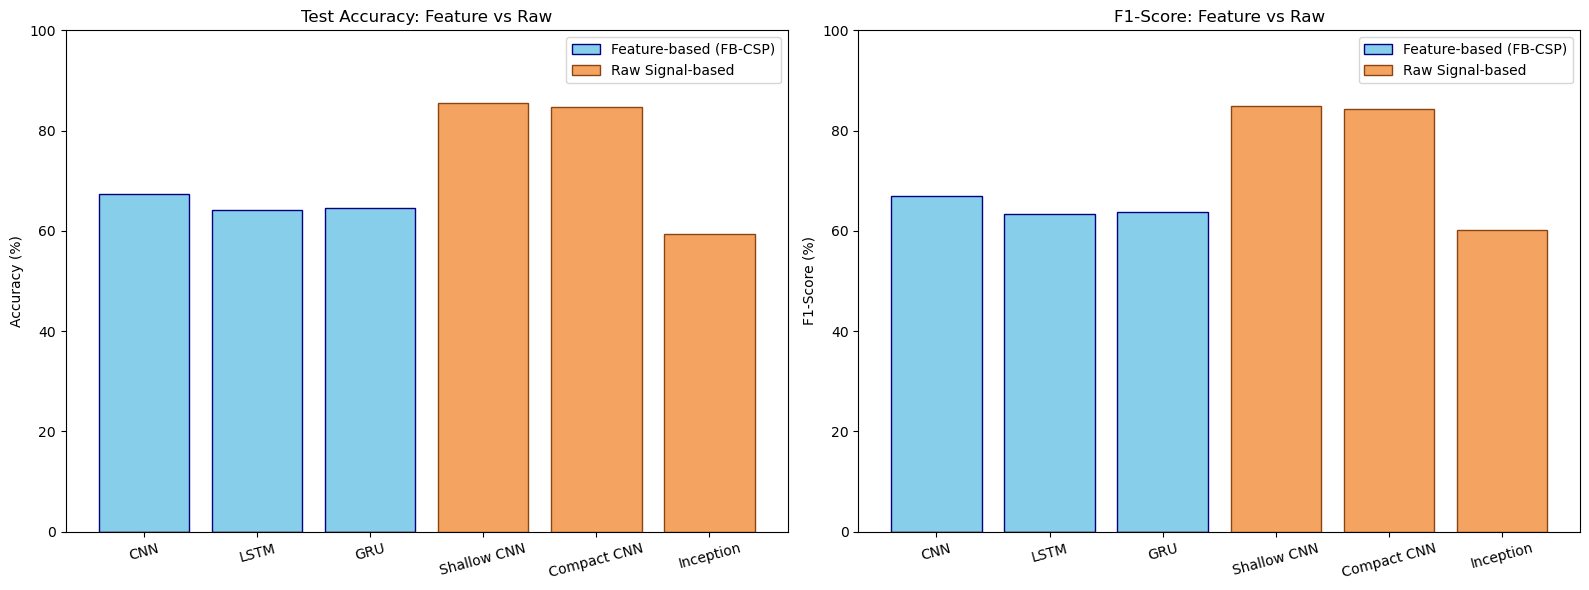

In [40]:
import matplotlib.pyplot as plt
import numpy as np

experiments = ['CNN', 'LSTM', 'GRU', 'Shallow CNN', 'Compact CNN', 'Inception']
y_cnn = cnn.predict(X_test_features_cnn)
y_lstm = lstm.predict(X_test_features_rnn)
y_gru = gru.predict(X_test_features_rnn)
y_shallow = shallow.predict(X_test)
y_compact_cnn = eegnet.predict(X_test)
y_inception = inception.predict(X_test)

y_pred_cnn = np.argmax(y_cnn, axis=1)
y_pred_lstm = np.argmax(y_lstm, axis=1)
y_pred_gru = np.argmax(y_gru, axis=1)
y_pred_shallow = np.argmax(y_shallow, axis=1)
y_pred_compact_cnn = np.argmax(y_compact_cnn, axis=1)
y_pred_inception = np.argmax(y_inception, axis=1)

y_true_labels = np.argmax(y_test, axis=1)   



# --- Calculate Metrics ---
# Group 1: Feature-based (CSP)
feat_metrics_acc = [
    accuracy_score(y_true_labels, y_pred_cnn) * 100,
    accuracy_score(y_true_labels, y_pred_lstm) * 100,
    accuracy_score(y_true_labels, y_pred_gru) * 100,
    0, 0, 0 # Placeholders for the raw slots
]

# Group 2: Raw-based
raw_metrics_acc = [
    0, 0, 0, # Placeholders for the feature slots
    accuracy_score(y_true_labels, y_pred_shallow) * 100,
    accuracy_score(y_true_labels, y_pred_compact_cnn) * 100,
    accuracy_score(y_true_labels, y_pred_inception) * 100,
]

# (Repeat same logic for F1)
feat_metrics_f1 = [
    f1_score(y_true_labels, y_pred_cnn, average='weighted') * 100,
    f1_score(y_true_labels, y_pred_lstm, average='weighted') * 100,
    f1_score(y_true_labels, y_pred_gru, average='weighted') * 100,
    0, 0, 0
]
raw_metrics_f1 = [
    0, 0, 0,
    f1_score(y_true_labels, y_pred_shallow, average='weighted') * 100,
    f1_score(y_true_labels, y_pred_compact_cnn, average='weighted') * 100,
    f1_score(y_true_labels, y_pred_inception, average='weighted') * 100,
]

# --- Plotting ---
x = np.arange(len(experiments))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy Plot
ax1.bar(x, feat_metrics_acc, label='Feature-based (FB-CSP)', color='skyblue', edgecolor='navy')
ax1.bar(x, raw_metrics_acc, label='Raw Signal-based', color='sandybrown', edgecolor='saddlebrown')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Test Accuracy: Feature vs Raw')
ax1.set_xticks(x)
ax1.set_xticklabels(experiments, rotation=15)
ax1.set_ylim(0, 100)
ax1.legend()

# F1 Plot
ax2.bar(x, feat_metrics_f1, color='skyblue',label='Feature-based (FB-CSP)', edgecolor='navy')
ax2.bar(x, raw_metrics_f1, color='sandybrown',label='Raw Signal-based', edgecolor='saddlebrown')
ax2.set_ylabel('F1-Score (%)')
ax2.set_title('F1-Score: Feature vs Raw')
ax2.set_xticks(x)
ax2.set_xticklabels(experiments, rotation=15)
ax2.set_ylim(0, 100)
ax2.legend()

plt.tight_layout()
plt.show()